In [71]:
from dataclasses import dataclass
from typing import Sequence, Any
from pathlib import Path

import numpy as np
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from numpy.typing import NDArray

In [72]:
"""Define common types and constants that may be used throughout the notebook"""

type PixCoords = tuple[NDArray[np.int64], NDArray[np.int64]]
type PixOffsets = tuple[int, int]
type PSF = NDArray[np.float64]
type Beam = NDArray[np.float64]
type Dirty = NDArray[np.float64]
type Residual = NDArray[np.float64]
type Image = NDArray[np.float64]
type Model = NDArray[np.float64]

SAMPLING = 5

@dataclass
class Source:
    x: int | float
    """Location in pixel grid in first dimension"""
    y: int | float
    """Location in pixel grid in second dimension"""
    flux: float
    """Brightness of the peak response"""

type Sources = Sequence[Source]




The dimension of PixCoords: 2
0 - (100, 100)
1 - (100, 100)


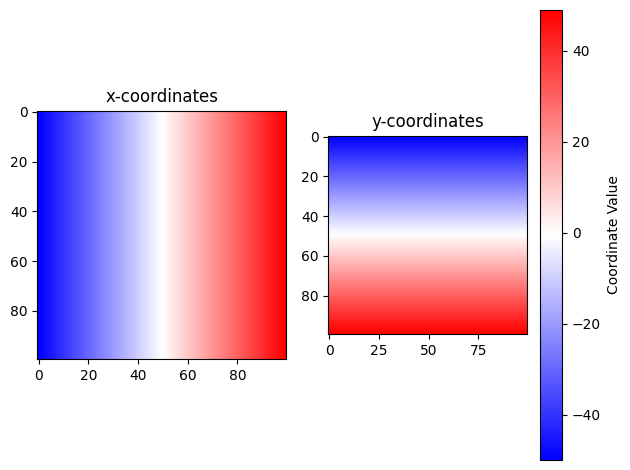

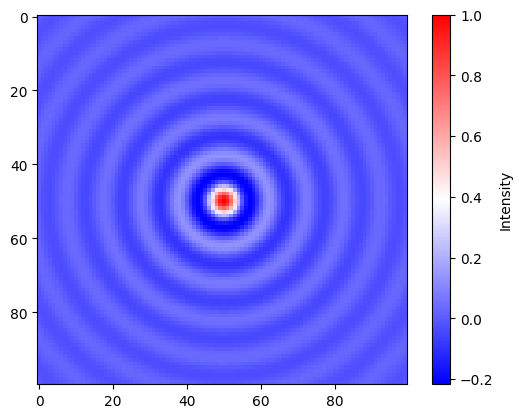

In [81]:
def plot_coords(pix_coords: PixCoords) -> None:
    """Sanity check the coordinate system"""

    print(f"The dimension of PixCoords: {len(pix_coords)}")
    for idx, direction in enumerate(pix_coords):
        print(f"{idx} - {direction.shape}")
    
    fig, axes = plt.subplots(1,2)
        
    axes[0].imshow(pix_coords[0], cmap="bwr")
    axes[0].set(title="x-coordinates")
    cim = axes[1].imshow(pix_coords[1], cmap="bwr")
    axes[1].set(title="y-coordinates")
    
    fig.colorbar(cim, label="Coordinate Value")
    fig.tight_layout()

    
    
def make_coord_grid(nx: int, ny: int) -> PixCoords:
    """Make up an initial pixel coordinate grid with the origin at the center

    Args:
        nx (int): Size of the image in the x-direction
        ny (int): Size of the image in the y-direction

    Returns:
        PixCoords: The coordinate grid
    """
    pix_x = np.arange(nx) - nx // 2
    pix_y = np.arange(ny) - ny // 2
    
    coords = np.meshgrid(pix_x.astype(int), pix_y.astype(int))

    return coords 


def plot_psf(psf: PSF | Beam, cbar: bool = True) -> None:
    """Sanity check the PSF"""

    fig, ax = plt.subplots(1,1)
    
    cim = ax.imshow(psf, cmap="bwr")
    if cbar:
        fig.colorbar(cim, label="Intensity")



def plot_psf_and_beam(psf: PSF, beam: Beam) -> None:
    """Make a comparison plot between the sinc PSF and the ideal Gaussian PSF"""
    v_max = 1
    v_min = -1
    cmap = "bwr"

    fig, (ax1, ax2) = plt.subplots(1,2)

    cm1 = ax1.imshow(psf, vmax=v_max, vmin=v_min, cmap=cmap)
    ax1.set(title="Dirty Beam")
    ax1.grid()
    
    cm2 = ax2.imshow(beam, vmax=v_max, vmin=v_min, cmap=cmap)
    ax2.set(title="Restoring Beam")
    ax2.grid()
    
    fig.colorbar(cm2, label="Response")
    fig.savefig("sinc_and_beam.png", bbox_inches="tight")



def radial_sinc(pix_coords: PixCoords, pix_offsets: PixOffsets | None = None) -> PSF:
    """Make up a PSF of the system"""

    if pix_offsets:
        # This will shift the origin of the response
        pix_coords = (
            pix_coords[0] - pix_offsets[0],
            pix_coords[1] - pix_offsets[1],
        )

    radius = np.sqrt(pix_coords[0]**2 + pix_coords[1]**2)
    
    radius /= SAMPLING
    
    return np.sinc(radius)

def radial_gauss(pix_coords: PixCoords, pix_offsets: PixOffsets | None = None) -> Beam:
    
    if pix_offsets:
        # This will shift the origin of the response
        pix_coords = (
            pix_coords[0] - pix_offsets[0],
            pix_coords[1] - pix_offsets[1],
        )

    radius = np.sqrt(pix_coords[0]**2 + pix_coords[1]**2)
    
    radius /= SAMPLING

    return np.exp(-radius**2/0.5)


pix_coords = make_coord_grid(nx=100, ny=100)
plot_coords(pix_coords=pix_coords)

psf = radial_sinc(pix_coords=pix_coords)
plot_psf(psf=psf)
    


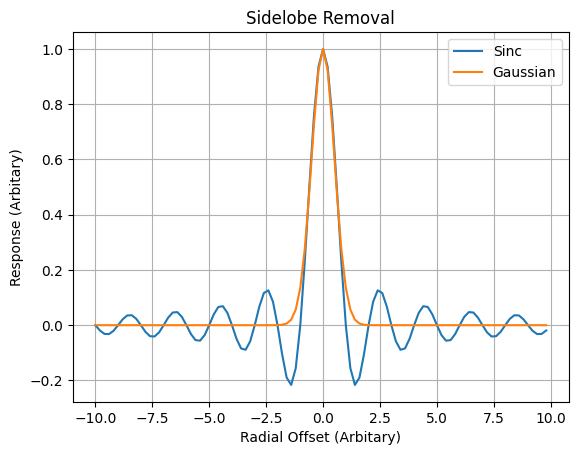

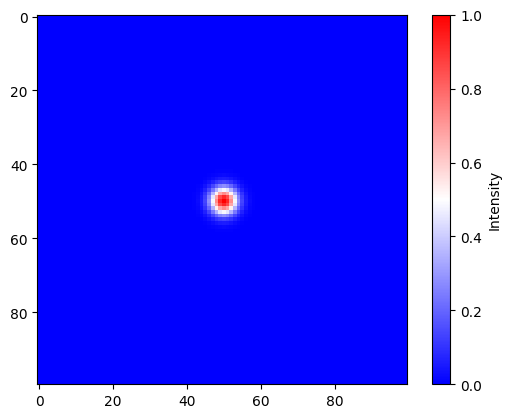

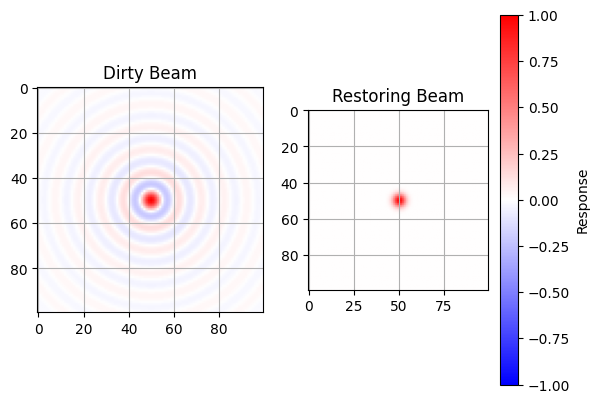

In [84]:
def compare_responses() -> None:
    impulse = (np.arange(100) - 50) / 5

    sinc_impulse = np.sinc(impulse)
    gauss_impulse = np.exp(-impulse**2 / 0.5)

    fig, ax = plt.subplots(1,1)

    ax.plot(
        impulse, sinc_impulse, label="Sinc"
    )
    ax.plot(
        impulse, gauss_impulse, label="Gaussian"
    )
    ax.legend()
    ax.grid()
    ax.set(
        title="Sidelobe Removal",
        ylabel="Response (Arbitary)",
        xlabel="Radial Offset (Arbitary)"
    )

    fig.savefig("one_d_response.png", bbox_inches="tight")


compare_responses()

gauss = radial_gauss(pix_coords=pix_coords)
plot_psf(psf=gauss)

plot_psf_and_beam(psf=psf, beam=gauss)



Plotting shifted response (-40, -40)
Plotting shifted response (-40, 0)
Plotting shifted response (-40, 40)
Plotting shifted response (0, -40)
Plotting shifted response (0, 0)
Plotting shifted response (0, 40)
Plotting shifted response (40, -40)
Plotting shifted response (40, 0)
Plotting shifted response (40, 40)


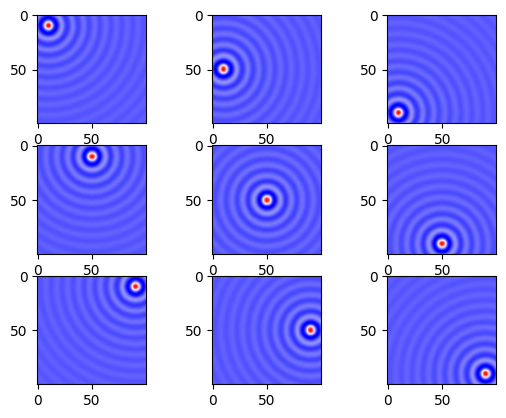

In [89]:
def plot_sinc_offsets(pix_coords: PixCoords, offsets: list[int] | None = None) -> None:
    """A simple helper function to display our the PSF function
    can be shifted around"""

    if offsets is None:
        offsets = [-40, 0, 40]
    
    n_offsets = len(offsets)
    fig, axes = plt.subplots(n_offsets, n_offsets)
    
    for i, x_offset in enumerate(offsets):
        for j, y_offset in enumerate(offsets):
            ax = axes[i, j]
            pix_offset = (x_offset, y_offset)
            print(f"Plotting shifted response {pix_offset}")
            response = radial_sinc(
                pix_coords=pix_coords, pix_offsets=pix_offset
            )

            ax.imshow(response, cmap="bwr")
            
    fig.savefig("sinc_shift.png", bbox_inches="tight")

plot_sinc_offsets(pix_coords=pix_coords)




Have created 5 sources
Generating source 0
Generating source 1
Generating source 2
Generating source 3
Generating source 4


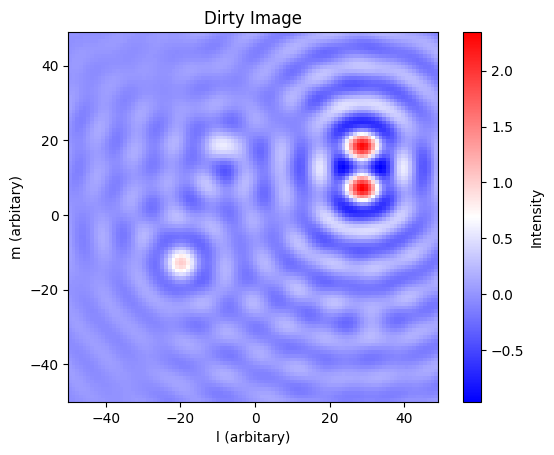

In [92]:
def make_source_response(pix_coords: PixCoords, source: Source) -> Image:
    """Helper to generate the source response for a given pixel grid and source specificaiton"""
    source_offset = (source.x, source.y)
    source_response = radial_sinc(
        pix_coords=pix_coords, pix_offsets=source_offset
    )

    return source_response * source.flux
    

def get_sources() -> Sources:
    """This is the sky model that we will be using to generate the dirty image."""
    sources = [
        Source(x=-20, y=12, flux=1.0),
        Source(x=32, y=29, flux=0.3),
        Source(x=-8, y=-20, flux=0.7),
        Source(x=29, y=-19, flux=2.3),
        Source(x=29, y=-9, flux=2.3),
    ]
    print(f"Have created {len(sources)} sources")
    return sources

def plot_dirty(dirty: Dirty, extent: tuple[float, float, float, float]) -> None:
    """Make a quick look plot of the dirty image"""


    fig, ax = plt.subplots(1, 1)
    
    cim = ax.imshow(dirty, cmap="bwr", extent=extent)
    ax.set(
        title="Dirty Image",
        xlabel="l (arbitary)",
        ylabel="m (arbitary)"
    )
    fig.colorbar(cim, label="Intensity")
    fig.savefig("dirty_map.png", bbox_inches="tight")
    

def make_source_image(pix_coords: PixCoords, sources: Sources) -> Dirty:
    """Generate the image of sources in the field"""
    dirty = np.zeros(pix_coords[0].shape, dtype=np.float64)
    
    for idx, source in enumerate(sources):
        print(f"Generating source {idx}")    
        source_response = make_source_response(
            pix_coords=pix_coords, source=source
        )
        dirty += source_response
        
    return dirty

        
sources = get_sources()
dirty = make_source_image(pix_coords=pix_coords, sources=sources)
plot_dirty(dirty=dirty, extent=(np.min(pix_coords[0]), np.max(pix_coords))*2)



Initialising the residual image
Iteration 1, on peak flux peak_flux=2.345 at offset (np.int64(-8), np.int64(29))
Iteration 2, on peak flux peak_flux=2.262 at offset (np.int64(-20), np.int64(29))
Iteration 3, on peak flux peak_flux=2.082 at offset (np.int64(-8), np.int64(29))
Iteration 4, on peak flux peak_flux=2.010 at offset (np.int64(-20), np.int64(29))
Iteration 5, on peak flux peak_flux=1.849 at offset (np.int64(-8), np.int64(29))
Iteration 6, on peak flux peak_flux=1.785 at offset (np.int64(-20), np.int64(29))
Iteration 7, on peak flux peak_flux=1.654 at offset (np.int64(-9), np.int64(29))
Iteration 8, on peak flux peak_flux=1.616 at offset (np.int64(-19), np.int64(29))
Iteration 9, on peak flux peak_flux=1.488 at offset (np.int64(-9), np.int64(29))
Iteration 10, on peak flux peak_flux=1.454 at offset (np.int64(-19), np.int64(29))
Iteration 11, on peak flux peak_flux=1.339 at offset (np.int64(-9), np.int64(29))
Iteration 12, on peak flux peak_flux=1.309 at offset (np.int64(-19), n

'restor_image.png'

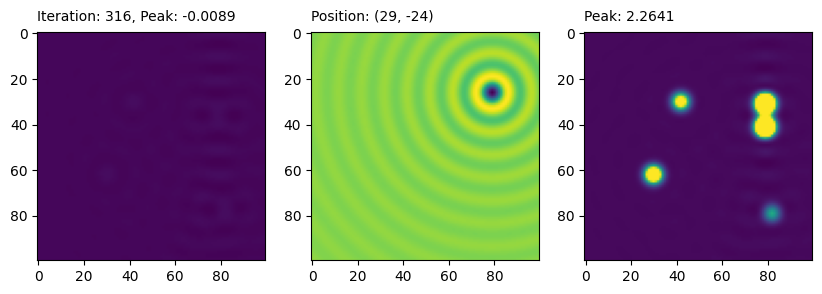

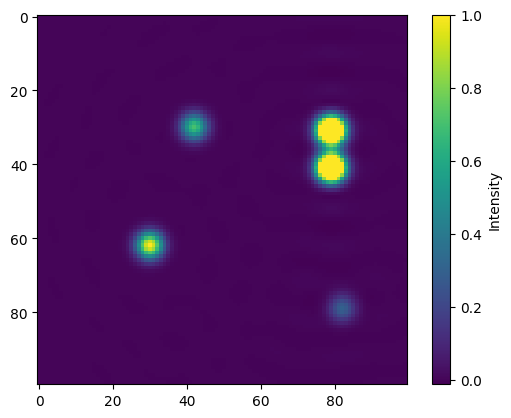

In [112]:
@dataclass
class CleanOptions:
    max_iterations: int
    """The maximum number of cleaning cycles that are allowed to be performed"""
    stopping_flux: float
    """The stopping flux level"""
    loop_gain: float
    """The gain factor to use per loop, e.g. residual = peak * loop_gain * PSF"""
    plot_iterations: bool = False
    """Plot throughout the cleaning"""
    noise: NDArray[np.floating] | None = None
    """Additional noise to add onto the image"""
    hide_psf: bool = False
    """Hide the PSF panel during the p[lotting]"""

@dataclass
class CleanResults:
    """Simple container to hold outputs from the cleaning process"""
    residual: Residual
    """The cleaning residuals"""
    model: Model
    """The clean components"""
    dirty: Dirty
    """The initial image that needed to be cleaned"""
    restor: Image
    """The final restored image"""
    frames: Any | None = None
    """Matplotlib axes frames to plot"""


@dataclass
class PeakInfo:
    """General information around the peak found"""
    location: tuple[int, int]
    """"The locaiton fo the peak"""
    offsets: PixOffsets
    """The offset location of the source relative to the reference pixel possiont"""
    flux: float
    """How bright the peak was"""
    iteration: int
    """The iteration count"""

def find_peak(residual: Residual, iteration: int) -> PeakInfo:
    """Find the locaiton of the peak asbolute in the residual   """

    peak_location = np.argmax(np.abs(residual))
    peak_location = np.unravel_index(peak_location, residual.shape)
    peak_flux = residual[peak_location]
    
    # Now calculate the offsets relative to the center of the iamge
    pix_offset = (
        peak_location[0] - residual.shape[0] // 2,
        peak_location[1] - residual.shape[1] // 2,
    )
    
    peak_info = PeakInfo(
        location=peak_location,
        offsets=tuple([int(o) for o in pix_offset[::-1]]),
        flux=peak_flux,
        iteration=iteration
    )
    print(f"Iteration {iteration}, on peak flux {peak_flux=:.3f} at offset {pix_offset}")
    
    return peak_info
    
def shift_scale_psf_minor_loop(
    pix_coords: PixCoords, peak_info: PeakInfo, loop_gain: float
) -> Image:
    """Make a shifted and scaled version of the PSF appropriate to subtract
    with in each minor loop."""

    scaled_psf = radial_sinc(
        pix_coords=pix_coords, 
        pix_offsets=peak_info.offsets
    )
    scaled_psf *= (peak_info.flux * loop_gain)
    return scaled_psf
    
def restored_beam_for_component(
    pix_coords: PixCoords, peak_info: PeakInfo, loop_gain: float
) -> Image:
    """Make a quick representation of the beam for a component. This is similar 
    to convolving the clean components using the fitted restoring beam."""
    
    scaled_beam = radial_gauss(
        pix_coords=pix_coords, 
        pix_offsets=peak_info.offsets    
    )
    scaled_beam *= (peak_info.flux * loop_gain)
    return scaled_beam
    
def plot_iteration(
    axes: tuple[plt.Axes,plt.Axes], 
    residual: Residual, 
    restor: Image, 
    model: Model,
    response: NDArray[np.float64], 
    peak_info: PeakInfo, 
    v_max: float | None = None
) -> None:
    """Create the artists that will be formed throughout the cleaning. This
    is not inteded to be used in a general sense."""
    
    

    psf_ax = None
    if len(axes) == 2:
        residual_ax, restor_ax = axes
    else:
        residual_ax, psf_ax, restor_ax = axes
    
    artist1 = residual_ax.imshow(residual, vmax=v_max)
    artist3 = restor_ax.imshow(restor, vmax=v_max)
    
    residual_title = residual_ax.text(
        0.0, 
        1.05, 
        f"Iteration: {peak_info.iteration}, Peak: {peak_info.flux:.4f}",
        transform=residual_ax.transAxes
    )
    
    restor_title = restor_ax.text(
        0.0, 
        1.05, 
        f"Peak: {np.max(restor):.4f}",
        transform=restor_ax.transAxes
    )
    
    artists = (artist1, artist3, residual_title, restor_title)
    
    # Deal with the option of hiding
    if psf_ax:
        artist2 = psf_ax.imshow(response)
        psf_title = psf_ax.text(
            0.0, 
            1.05,
            f"Position: {peak_info.offsets}",
            transform=psf_ax.transAxes
        )
        artists = artists + (artist2, psf_title)
        
    return artists
    
    
def clean(pix_coords: PixCoords, dirty: Dirty, clean_options: CleanOptions) -> CleanResults:
    """A simple clean algorithm using an analytic sinc function to represent the PSF. 

    Args:
        pix_coords (PixCoords): Coordinates of the image, origin at center of image
        dirty (Dirty): The dirty image that will be deconvolved
        clean_options (CleanOptions): Options controlling the clean process

    Returns:
        CleanResults: The results from the cleaning process
    """
    frames = []
    if clean_options.plot_iterations:
        plt.close("all")
        no_panels = 2 if clean_options.hide_psf else 3
        fig, axes = plt.subplots(1, no_panels, figsize=(10, 5))
            
    print("Initialising the residual image")
    residual = dirty.copy()
    restor = dirty.copy()
    model = np.zeros_like(residual)
    
    v_max = np.max(residual) * 0.5
    v_max = 0.5
    
    iteration = 0
    while True:
         
        iteration += 1
        
        # Find the peak
        peak_info = find_peak(residual=residual, iteration=iteration)
        # shift and scale the PSF to the peak position
        scaled_psf = shift_scale_psf_minor_loop(
            pix_coords=pix_coords, peak_info=peak_info, loop_gain=clean_options.loop_gain
        )
        
        # Do the book keeping
        model[peak_info.location] += peak_info.flux
        residual -= scaled_psf
        
        if clean_options.plot_iterations:
            # This is purely for the plotting
            restor_component = restored_beam_for_component(
                pix_coords=pix_coords, peak_info=peak_info, loop_gain=clean_options.loop_gain
            )
            restor -= scaled_psf
            restor += restor_component
            
            _axes = plot_iteration(
                axes=axes, residual=residual, response=scaled_psf, restor=restor, model=model, peak_info=peak_info, v_max=v_max
            )
            frames.append(_axes)
        
        
        if iteration >= clean_options.max_iterations:
            print("Maximum number of iterations reached")
            break
        if np.abs(peak_info.flux) < clean_options.stopping_flux:
            print("Have reached the clean threshold")
            break

    return CleanResults(
        residual=residual, model=model, dirty=dirty, restor=restor, frames=(fig, frames)
    )

def run_cleaner(
    pix_coords: PixCoords, 
    dirty: Dirty,
    clean_options: CleanOptions, 
    out_path: Path, 
    fps: int = 5,
) -> CleanResults:

    if clean_options.noise is not None:
        print("Adding provided noise onto the dirty image")
        dirty = dirty + clean_options.noise
    
    clean_results = clean(pix_coords=pix_coords, dirty=dirty, clean_options=clean_options)

    if clean_results.frames is not None:
        print(f"Making animation with {len(clean_results.frames[1])} frames")
        clean_animation = animation.ArtistAnimation(
            *clean_results.frames, blit=True, interval=50
        )
        clean_animation.save(out_path, writer="ffmpeg", fps=fps)
        print("Finished animation")

    return clean_results

def plot_restor(image: Image, out_path: Path, **kwargs) -> Path:
    """Quickly ploit the restored image (or something)"""
    fig, ax = plt.subplots(1, 1)
    
    cim = ax.imshow(
        image, **kwargs
    )
    fig.colorbar(cim, label="Intensity")
    fig.savefig(out_path, bbox_inches="tight")
    
    return out_path

clean_options = CleanOptions(
    max_iterations=400, 
    stopping_flux=0.009, 
    loop_gain=0.1,
    plot_iterations=True,
)
clean_results = run_cleaner(
    pix_coords=pix_coords, dirty=dirty, clean_options=clean_options, out_path=Path("clean_animation.mp4")
)

plot_restor(
    image=clean_results.restor, out_path="restor_image.png", vmax=1
)




Adding provided noise onto the dirty image
Initialising the residual image
Iteration 1, on peak flux peak_flux=2.425 at offset (np.int64(-8), np.int64(30))
Iteration 2, on peak flux peak_flux=2.266 at offset (np.int64(-19), np.int64(29))
Iteration 3, on peak flux peak_flux=2.163 at offset (np.int64(-8), np.int64(30))
Iteration 4, on peak flux peak_flux=2.032 at offset (np.int64(-20), np.int64(30))
Iteration 5, on peak flux peak_flux=1.991 at offset (np.int64(-9), np.int64(28))
Iteration 6, on peak flux peak_flux=1.842 at offset (np.int64(-19), np.int64(29))
Iteration 7, on peak flux peak_flux=1.791 at offset (np.int64(-9), np.int64(28))
Iteration 8, on peak flux peak_flux=1.657 at offset (np.int64(-19), np.int64(29))
Iteration 9, on peak flux peak_flux=1.625 at offset (np.int64(-8), np.int64(30))
Iteration 10, on peak flux peak_flux=1.497 at offset (np.int64(-9), np.int64(28))
Iteration 11, on peak flux peak_flux=1.476 at offset (np.int64(-19), np.int64(29))
Iteration 12, on peak flux 

'bad_restor_image.png'

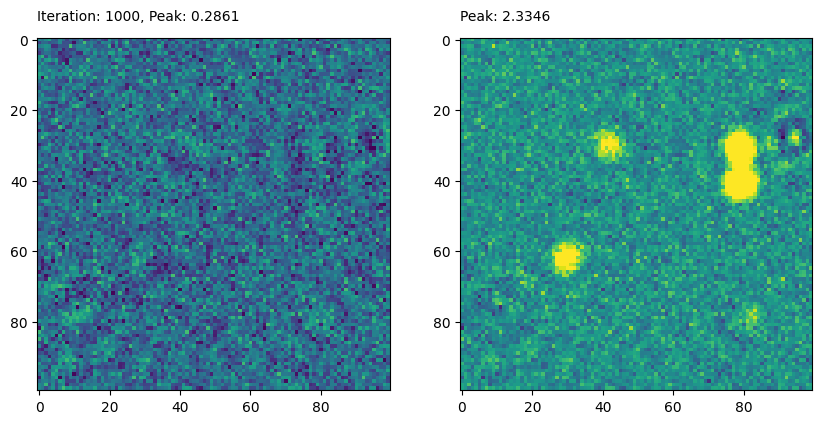

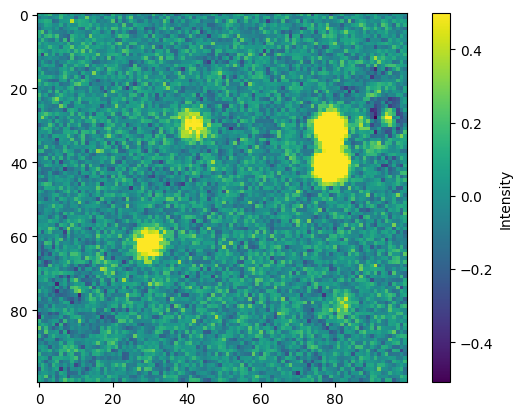

In [113]:
np.random.seed(42)
noise = np.random.normal(loc=0, scale=0.1, size=dirty.size).reshape(dirty.shape)

clean_options = CleanOptions(
    max_iterations=1000, 
    stopping_flux=0.00001, 
    loop_gain=0.1,
    plot_iterations=True,
    noise=noise,
    hide_psf=True,
)


clean_results = run_cleaner(
    pix_coords=pix_coords, dirty=dirty, clean_options=clean_options, out_path=Path("bad_clean_animation.mp4"), fps=20
)

plot_restor(
    image=clean_results.restor, out_path="bad_restor_image.png", vmax=0.5
)
